In [1]:
import json
import pickle
import logging
import os
import warnings

import joblib
import mlflow
import numpy as np
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, precision_recall_fscore_support, 
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
warnings.filterwarnings("ignore")

/home/brian02oriel/Documents/Platzi Courses/ml-courses/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def read_csv(file_name: str, path="data/data_processed/") -> pd.DataFrame:
    """
    Read csv file
    :param file_name: file name
    :param path: path to the file
    :return: pandas dataframe
    """
    return pd.read_csv(os.path.join(path, file_name))

In [ ]:
df_tickets = read_csv("tickets_inputs_eng_1.csv")

In [ ]:
df_tickets.shape

(18957, 4)

In [ ]:
df_tickets.sample(5)

,complaint_what_happened,ticket_classification,processed_text,relevant_topics
10021,A check from the XXXX XXXX XXXX XXXX through J...,Bank account or service + Other bank product/s...,check jpmorg bank york cash check payabl bank run,Mortgage/Loan
7863,Chase reported that my Chase auto account is d...,"Credit reporting, credit repair services, or o...",report chas aut account tim agre balanc balanc,Mortgage/Loan
16870,Chase removed my autopay 14 months after I set...,Consumer Loan + Vehicle lease,chas autopay i account delinquent i report acc...,Mortgage/Loan
3489,Someone opened accounts in my name and have st...,Checking or savings account + Checking account,someon nam hav stol identity i security shelt ...,Mortgage/Loan
6719,We arrived at the Chase Business drive-thru at...,Checking or savings account + Checking account,chas business drive-thru i deposit slip draw m...,Mortgage/Loan


In [ ]:
df_tickets.relevant_topics.value_counts()

relevant_topics
Mortgage/Loan                    16648
Bank Account Services             2132
Credit Report or Prepaid Card      177
Name: count, dtype: int64

In [ ]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("tickets_baseline")

skops_trusted_types=['sklearn.metrics._classification.f1_score', 'sklearn.metrics._scorer._Scorer', 'sklearn.model_selection._split.StratifiedKFold']


def data_transform(df: pd.DataFrame):
    """This function transform the data into X and y
    Args:
      df (pd.DataFrame): dataframe with the data
    Returns:
      X (pd.Series): series with the text
      y (pd.Series): series with the labels"""
    X = df["processed_text"]
    y = df["relevant_topics"]

    return X, y


def read_idx2label(json_path: str) -> pd.Series:
    """This function read the json file and return a dictionary
    Args:
      json_path (str): path to the json file
     Returns:
      idx2label (dict): dictionary with the mapping"""
    with open(json_path) as f:
        idx2label = json.load(f)
    return idx2label


def decode_labels_into_idx(labels: pd.Series, idx2label: dict) -> pd.Series:
    """This function decode the labels into idx
    Args:
      labels (pd.Series): series with the labels
      idx2label (dict): dictionary with the mapping
     Returns:
      labels (pd.Series): series with the labels decoded
    """
    return labels.map(idx2label)


def fit_transform(X: pd.Series) -> np.ndarray:
    count_vectorizer = CountVectorizer()
    X_vectorized = count_vectorizer.fit_transform(X)
    #save count vectorizer for data preprocessing in the main app (deploy)
    joblib.dump(count_vectorizer, 'data/data_processed/count_vectorizer.pkl')
    logger.info("count vectorizer trained successfully stored")
    return X_vectorized


def transform_tfidf(X_vectorized: object) -> np.ndarray:
    tfidf_transformer = TfidfTransformer()
    X_tfidf = tfidf_transformer.fit_transform(X_vectorized)
    joblib.dump(X_tfidf, 'data/data_processed/X_tfidf.pkl')
    logger.info("X_tfidf trained successfully stored")
    return X_tfidf

def save_pickle(data, filename) -> None:
    """
    This function saves the data in a pickle file
    Args:
        data (object): data to save
        filename (str): filename
    Returns:
        None
    """
    filepath = os.path.join("data", "data_processed", f"{filename}.pkl")
    with open(filepath, 'wb') as file:
        pickle.dump(data, file)

def split_train_test(
    X_tfidf: np.array, y: pd.Series, test_size: float = 0.3, random_state: int = 42
) -> tuple:
    """
    This function splits the data into train and test
    Args:
      X_tfidf (np.array): array with the vectorized data
      y (pd.Series): series with the labels
      test_size (float): test size
      random_state (int): random state
    Returns:
      X_train (np.array): array with the vectorized data for train
      X_test (np.array): array with the vectorized data for test
      y_train (pd.Series): series with the labels for train
      y_test (pd.Series): series with the labels for test
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X_tfidf, y, test_size=test_size, random_state=random_state
    )
    save_pickle((X_train, y_train), "train")
    save_pickle((X_test, y_test),  "test")
    logger.info("data saved successfully in pickle files")
    return X_train, X_test, y_train, y_test

def display_classification_report(
    model: object,
    name_model: str,
    developer: str,
    X_train: np.array,
    X_test: np.array,
    y_train: np.array,
    y_test: np.array,
    use_cv = False
):
    """This function display the classification report
    Args:
      model (object): model
      name_model (str): name of the model
      developer (str): developer name
      X_train (np.array): array with the vectorized data for train
      X_test (np.array): array with the vectorized data for test
      y_train (pd.Series): series with the labels for train
      y_test (pd.Series): series with the labels for test
     Returns:
      metric (list): list with the metrics"""
    
    print("------------------- NAME MODEL ------------------- | ", name_model)
    # star experiment in mlflow
    with mlflow.start_run(run_name=name_model):
        mlflow.log_param("model", name_model)
        mlflow.log_param("developer", developer)
        # empty list to store the metrics and then tracking them in mlflow
        metric = []
        y_train_pred_proba = model.predict_proba(X_train)
        y_test_pred_proba = model.predict_proba(X_test)
        roc_auc_score_train = round(
            roc_auc_score(
                y_train, y_train_pred_proba, average="weighted", multi_class="ovr"
            ),
            2,
        )
        roc_auc_score_test = round(
            roc_auc_score(
                y_test, y_test_pred_proba, average="weighted", multi_class="ovr"
            ),
            2,
        )

        logger.info("ROC AUC Score Train:", roc_auc_score_train)
        logger.info("ROC AUC Score Test:", roc_auc_score_test)
        
        # adding the metrics to the list
        metric.extend([roc_auc_score_train, roc_auc_score_test])

        mlflow.log_metric("roc_auc_train", roc_auc_score_train)
        mlflow.log_metric("roc_auc_test", roc_auc_score_test)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        (
            precision_train,
            recall_train,
            fscore_train,
            support_train,
        ) = precision_recall_fscore_support(y_train, y_train_pred, average="weighted")
        (
            precision_test,
            recall_test,
            fscore_test,
            support_test,
        ) = precision_recall_fscore_support(y_test, y_test_pred, average="weighted")

        mlflow.log_metric("precision_train", precision_train)
        mlflow.log_metric("precision_test", precision_test)
        mlflow.log_metric("recall_train", recall_train)
        mlflow.log_metric("recall_test", recall_test)
        
        try:
            if use_cv:
                best_params = model.best_params_
            else:
                best_params = model.get_params()
            mlflow.log_params(best_params)

        except AttributeError as e:
            logger.info(f"Error: {e}")

        mlflow.sklearn.log_model(model, f"model_{name_model}", skops_trusted_types=skops_trusted_types)

        acc_score_train = round(accuracy_score(y_train, y_train_pred), 2)
        acc_score_test = round(accuracy_score(y_test, y_test_pred), 2)

        metric.extend(
            [
                acc_score_train,
                acc_score_test,
                round(precision_train, 2),
                round(precision_test, 2),
                round(recall_train, 2),
                round(recall_test, 2),
                round(fscore_train, 2),
                round(fscore_test, 2),
            ]
        )

        print("Train Accuracy: ", acc_score_train)
        print("Test Accuracy: ", acc_score_test)

        model_report_train = classification_report(y_train, y_train_pred)
        model_report_test = classification_report(y_test, y_test_pred)

        print("Classification Report for Train:\n", model_report_train)
        print("Classification Report for Test:\n", model_report_test)

        # Plot the confusion matrix
        fig, ax = plt.subplots(figsize=(12, 8))

        # Create the confusion matrix with labels decoded
        decoded_y_test_pred = [idx2label[idx] for idx in y_test_pred]
        decoded_y_test = [idx2label[idx] for idx in y_test]

        cm = confusion_matrix(decoded_y_test, decoded_y_test_pred)
        cmp = ConfusionMatrixDisplay(cm, display_labels=list(idx2label.values()))
        cmp.plot(ax=ax)

        plt.xticks(rotation=80)
        plt.show()

        mlflow.sklearn.log_model(model, name_model, skops_trusted_types=skops_trusted_types)

        return metric


def grid_search(model, folds, params, scoring):
    """This function perform a grid search
    Args:
        model (object): model
        folds (int): number of folds
        params (dict): dictionary with the parameters
        scoring (str): scoring
    Returns:
        grid_search (object): grid search
    """

    grid_search = GridSearchCV(
        model, cv=folds, param_grid=params, scoring=scoring, n_jobs=-1, verbose=1
    )
    return grid_search


def print_best_score_params(model):
    """This functions print best score and best hyperparameters for baselines models
    Args:
        model (object): model
    Returns:
        None"""
    print("Best Score: ", model.best_score_)
    print("Best Hyperparameters: ", model.best_params_)

In [ ]:
idx2label = read_idx2label(json_path="data/data_processed/topic_mapping_1.json")
label2idx = {value: key for key, value in idx2label.items()}

X, y = data_transform(df_tickets)
y = decode_labels_into_idx(labels=y, idx2label=label2idx)

X_vectorized = fit_transform(X.values)
X_tfidf = transform_tfidf(X_vectorized)
X_train, X_test, y_train, y_test = split_train_test(X_tfidf, y)

INFO:__main__:count vectorizer trained successfully stored
INFO:__main__:X_tfidf trained successfully stored
INFO:__main__:data saved successfully in pickle files


------------------- NAME MODEL ------------------- |  MultinomialNB


--- Logging error ---
Traceback (most recent call last):
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call s

Train Accuracy:  0.88
Test Accuracy:  0.88
Classification Report for Train:
               precision    recall  f1-score   support

           0       0.33      0.00      0.00      1490
           1       0.00      0.00      0.00       119
           2       0.88      1.00      0.94     11660

    accuracy                           0.88     13269
   macro avg       0.40      0.33      0.31     13269
weighted avg       0.81      0.88      0.82     13269

Classification Report for Test:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       642
           1       0.00      0.00      0.00        58
           2       0.88      1.00      0.93      4988

    accuracy                           0.88      5688
   macro avg       0.29      0.33      0.31      5688
weighted avg       0.77      0.88      0.82      5688



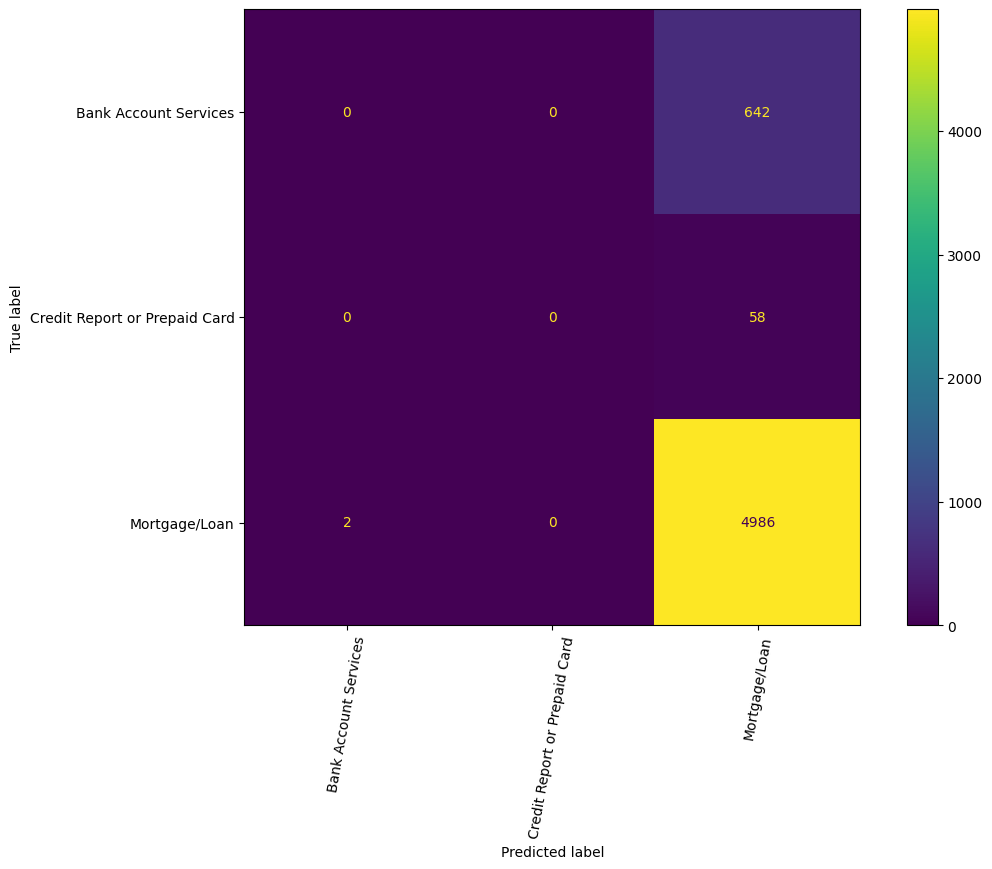

2026/06/20 13:32:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/20 13:32:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[0.62, 0.53, 0.88, 0.88, 0.81, 0.77, 0.88, 0.88, 0.82, 0.82]

In [ ]:

mnb = MultinomialNB()
mnb.fit(X_train, y_train)
display_classification_report(model=mnb, 
                              name_model="MultinomialNB", 
                              developer="Maria", 
                              X_train=X_train, 
                              X_test=X_test, 
                              y_train=y_train, 
                              y_test=y_test)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Score:  0.8785891957775688
Best Hyperparameters:  {'alpha': 1}
------------------- NAME MODEL ------------------- |  MultinomialNBCV


--- Logging error ---
Traceback (most recent call last):
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call s

Train Accuracy:  0.88
Test Accuracy:  0.88
Classification Report for Train:
               precision    recall  f1-score   support

           0       0.33      0.00      0.00      1490
           1       0.00      0.00      0.00       119
           2       0.88      1.00      0.94     11660

    accuracy                           0.88     13269
   macro avg       0.40      0.33      0.31     13269
weighted avg       0.81      0.88      0.82     13269

Classification Report for Test:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       642
           1       0.00      0.00      0.00        58
           2       0.88      1.00      0.93      4988

    accuracy                           0.88      5688
   macro avg       0.29      0.33      0.31      5688
weighted avg       0.77      0.88      0.82      5688



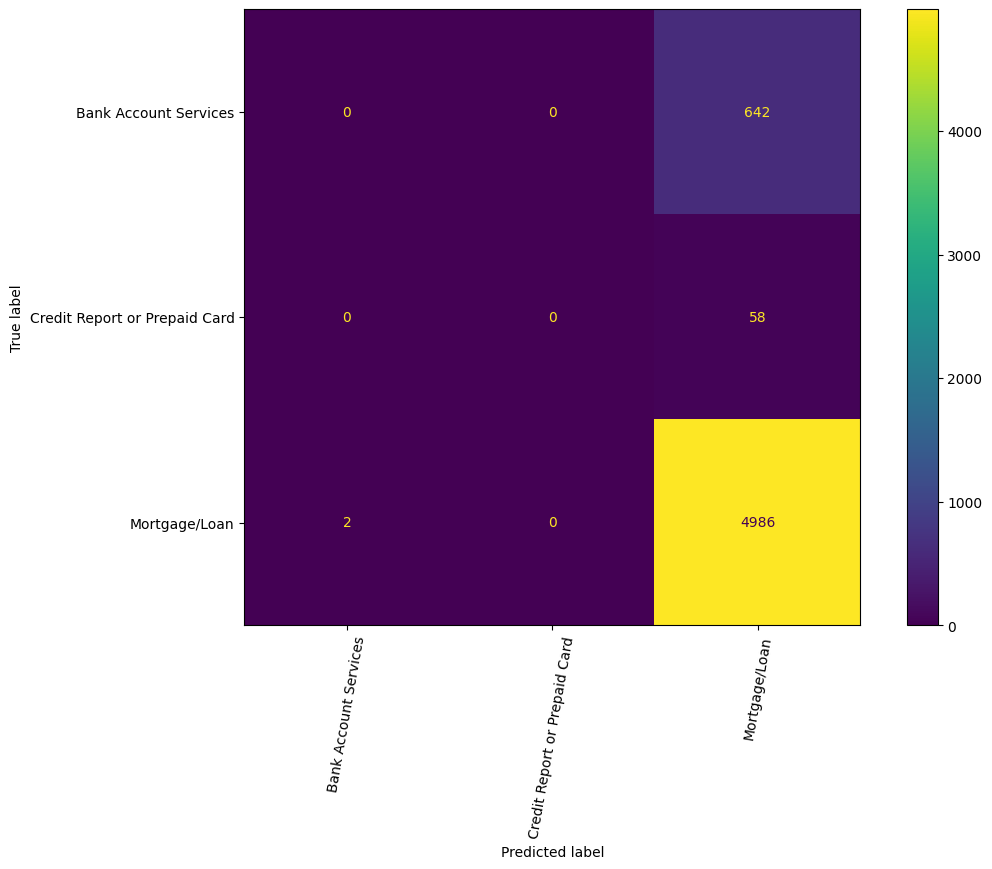

2026/06/20 13:32:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/20 13:32:32 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[0.62, 0.53, 0.88, 0.88, 0.81, 0.77, 0.88, 0.88, 0.82, 0.82]

In [ ]:
folds = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 40)
mnb = MultinomialNB()
mnb_params = {  
'alpha': (1, 0.1, 0.01, 0.001, 0.0001)  
}
grid_search_mnb = grid_search(mnb, folds, mnb_params, scoring="f1_micro")
grid_search_mnb.fit(X_train, y_train)
print_best_score_params(grid_search_mnb)

display_classification_report(model=grid_search_mnb, 
                              name_model="MultinomialNBCV", 
                              developer="Maria", 
                              X_train=X_train, 
                              X_test=X_test, 
                              y_train=y_train, 
                              y_test=y_test, 
                              use_cv= True)

------------------- NAME MODEL ------------------- |  LogisticRegression


--- Logging error ---
Traceback (most recent call last):
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call s

Train Accuracy:  0.88
Test Accuracy:  0.87
Classification Report for Train:
               precision    recall  f1-score   support

           0       0.73      0.03      0.06      1490
           1       0.00      0.00      0.00       119
           2       0.88      1.00      0.94     11660

    accuracy                           0.88     13269
   macro avg       0.54      0.34      0.33     13269
weighted avg       0.86      0.88      0.83     13269

Classification Report for Test:
               precision    recall  f1-score   support

           0       0.21      0.01      0.02       642
           1       0.00      0.00      0.00        58
           2       0.88      1.00      0.93      4988

    accuracy                           0.87      5688
   macro avg       0.36      0.34      0.32      5688
weighted avg       0.79      0.87      0.82      5688



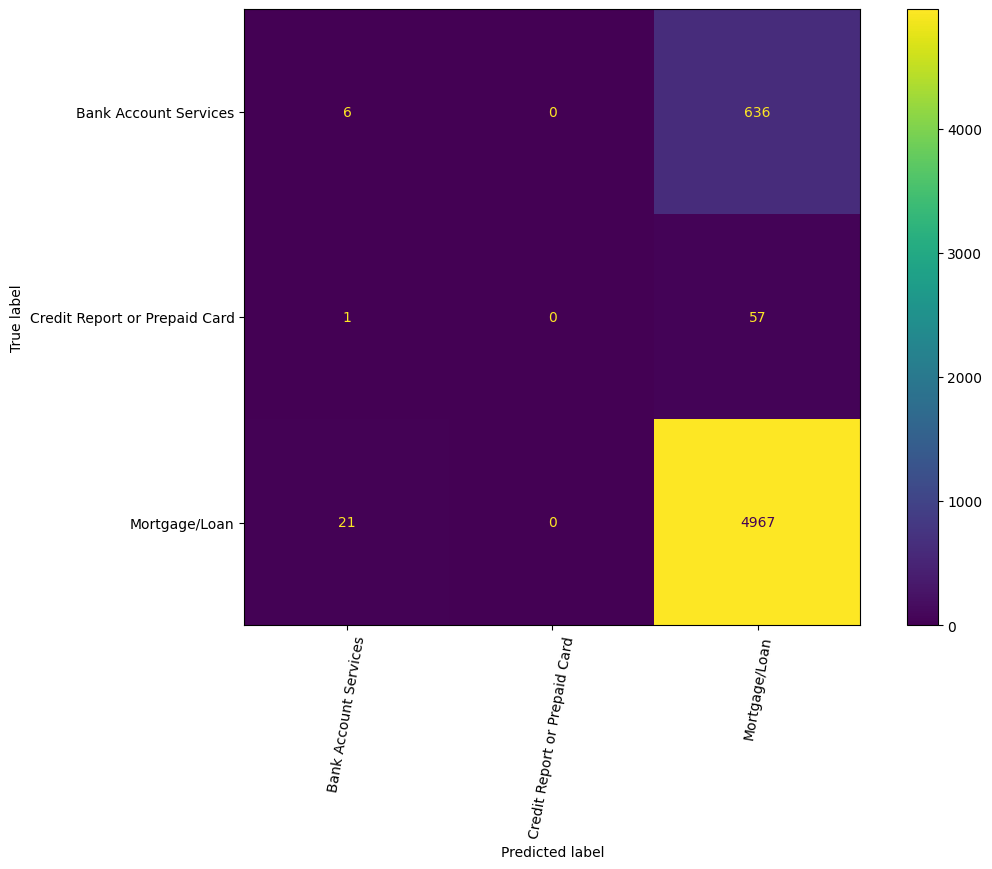

2026/06/20 13:32:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/20 13:32:59 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[0.86, 0.61, 0.88, 0.87, 0.86, 0.79, 0.88, 0.87, 0.83, 0.82]

In [ ]:
log_reg = LogisticRegression(random_state=40)
log_reg.fit(X_train,y_train)
display_classification_report(model=log_reg, 
                              name_model="LogisticRegression", 
                              developer="Maria", 
                              X_train=X_train, 
                              X_test=X_test, 
                              y_train=y_train, 
                              y_test=y_test, 
                              use_cv=False)

In [ ]:
# rebalance of the data
smote = SMOTE()
# transform the dataset with the SMOTE algorithm
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
# define the model with the balanced class_weight
log_reg = LogisticRegression(class_weight='balanced')

log_params = {'C': [0.01, 1, 10], 
          'penalty': ['l1', 'l2'],
          'solver': ['liblinear','newton-cg','saga']
         }

grid_search_log = grid_search(log_reg, folds, log_params, scoring="f1_micro")
grid_search_log.fit(X_train_res, y_train_res)  # entrenamiento con los datos rebalanceados

print_best_score_params(grid_search_log)
display_classification_report(grid_search_log,
                              name_model="LogisticRegressionCVSmote", 
                              developer="Maria", 
                              X_train=X_train_res,  # evaluación con los datos rebalanceados
                              X_test=X_test, 
                              y_train=y_train_res,  # etiquetas rebalanceadas
                              y_test=y_test, 
                              use_cv=True)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


Fitting 5 folds for each of 512 candidates, totalling 2560 fits
Best Score:  0.3645190847004367
Best Hyperparameters:  {'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 2, 'splitter': 'random'}
------------------- NAME MODEL ------------------- |  DecisionTreeClassifierCV


--- Logging error ---
Traceback (most recent call last):
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/home/brian02oriel/snap/code/247/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call s

Train Accuracy:  0.96
Test Accuracy:  0.79
Classification Report for Train:
               precision    recall  f1-score   support

           0       0.79      0.98      0.87      1490
           1       0.67      0.69      0.68       119
           2       1.00      0.97      0.98     11660

    accuracy                           0.96     13269
   macro avg       0.82      0.88      0.84     13269
weighted avg       0.97      0.96      0.97     13269

Classification Report for Test:
               precision    recall  f1-score   support

           0       0.15      0.16      0.16       642
           1       0.00      0.00      0.00        58
           2       0.88      0.88      0.88      4988

    accuracy                           0.79      5688
   macro avg       0.35      0.35      0.35      5688
weighted avg       0.79      0.79      0.79      5688



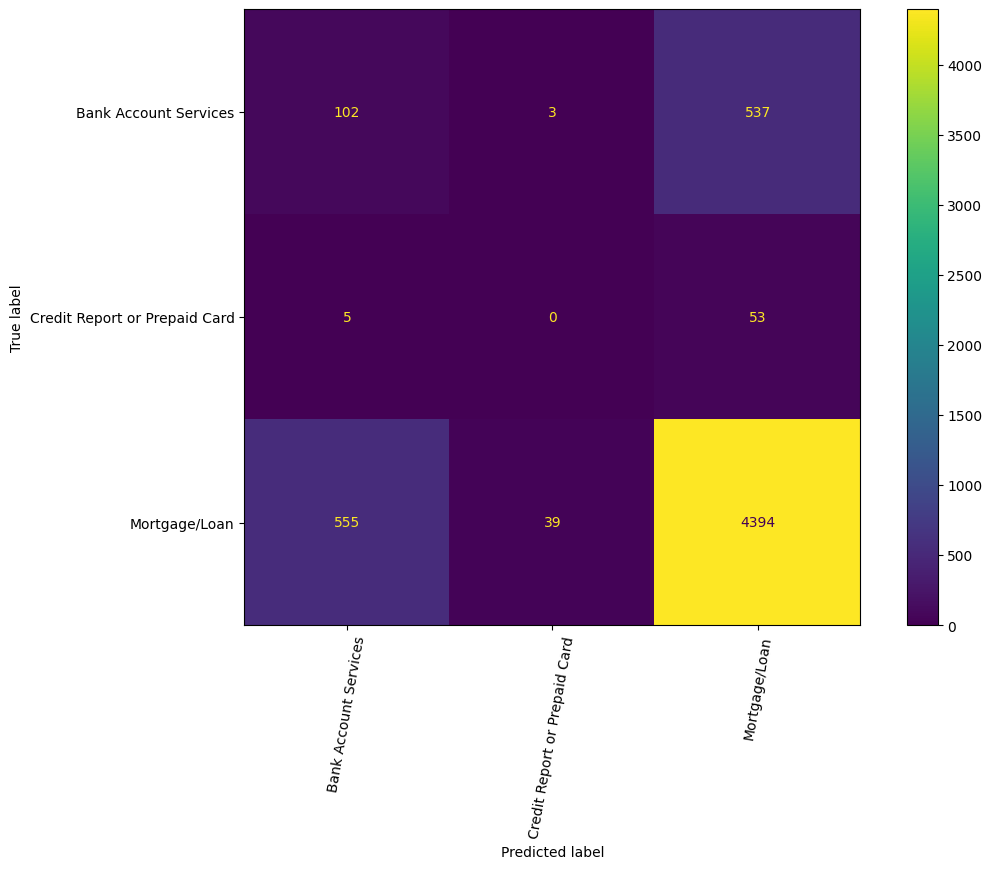

2026/06/20 13:20:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/20 13:20:58 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[0.99, 0.52, 0.96, 0.79, 0.97, 0.79, 0.96, 0.79, 0.97, 0.79]

In [ ]:
dtc_cv = DecisionTreeClassifier(random_state=40)

dtc_params = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [2,3,4,5,6,7,8,None],
    'min_samples_leaf': [2,3,4,7],
    'max_features': ['auto', 'sqrt', 'log2', None]
}
grid_search_dtc = grid_search(dtc_cv, folds, dtc_params, scoring='f1_macro')
grid_search_dtc.fit(X_train, y_train)
print_best_score_params(grid_search_dtc)
display_classification_report(grid_search_dtc, 
                              name_model="DecisionTreeClassifierCV", 
                              developer="Maria", 
                              X_train=X_train, 
                              X_test=X_test, 
                              y_train=y_train, 
                              y_test=y_test, 
                              use_cv=True)